# Bitcoin Month, Week, Day

In this activity, you’ll use the `loc` function to find time periods in the two Bitcoin DataFrames that differ in the closing price. 

Instructions:

1. Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a period of one month.

2. Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a period of a week in the month that you selected.

3. Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a single day of the week that you selected.

4. Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a couple of hours during the day that you selected.


### Import the required libraries and dependencies.

In [1]:
import pandas as pd
from pathlib import Path

### Use the `Path` module and `read_csv` functions to import the CSV files and create the bitcoin_1 and bitcoin_2 DataFrames.

In [2]:
# Read in the CSV file called "bitcoin_1.csv" using the Path module. 
# The CSV file is located in the Resources folder.
# Set the index to the column "Timestamp"
# Set the parse_dates and infer_datetime_format parameters
bitcoin_1 = pd.read_csv(
    Path('03-Bitcoin_Month_Week_Day/Resources/bitcoin_1.csv'), 
    index_col="Timestamp", 
    parse_dates=True, 
    infer_datetime_format=True
)

# Review the first 5 rows of the 'bitcoin_1' DataFrame
bitcoin_1.head()

/var/folders/s9/ml6qrgdx03zdn76qyj8422mh0000gn/T/ipykernel_2016/3178016335.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  bitcoin_1 = pd.read_csv(


,Close
Timestamp,
2015-01-01 00:00:00,314.0
2015-01-01 00:01:00,314.0
2015-01-01 00:02:00,314.0
2015-01-01 00:03:00,314.0
2015-01-01 00:04:00,313.9


In [3]:
bitcoin_2 = pd.read_csv(
    Path('03-Bitcoin_Month_Week_Day/Resources/bitcoin_2.csv'), 
    index_col="Timestamp", 
    parse_dates=True
)

bitcoin_2.head()

,Close
Timestamp,
2015-01-07 20:24:00,360.00
2015-01-07 20:27:00,276.34
2015-01-07 20:28:00,271.60
2015-01-07 20:29:00,344.67
2015-01-07 20:30:00,305.38


### Use the `describe` function to generate summary statistics for the bitcoin_1 and bitcoin_2 DataFrames.

In [4]:
bitcoin_1.describe()

,Close
count,372773.000000
mean,274.423996
std,61.778634
min,153.100000
25%,233.850000
50%,248.950000
75%,288.820000
max,501.960000


In [5]:
bitcoin_2.describe()

,Close
count,440797.000000
mean,275.956285
std,60.728446
min,109.940000
25%,235.810000
50%,250.540000
75%,289.260000
max,499.260000


### Create the overlay plot that visualizes the two Bitcoin DataFrames for 2015.  

<Axes: title={'center': 'Bitcoin_1 v. Bitcoin_2'}, xlabel='Timestamp'>

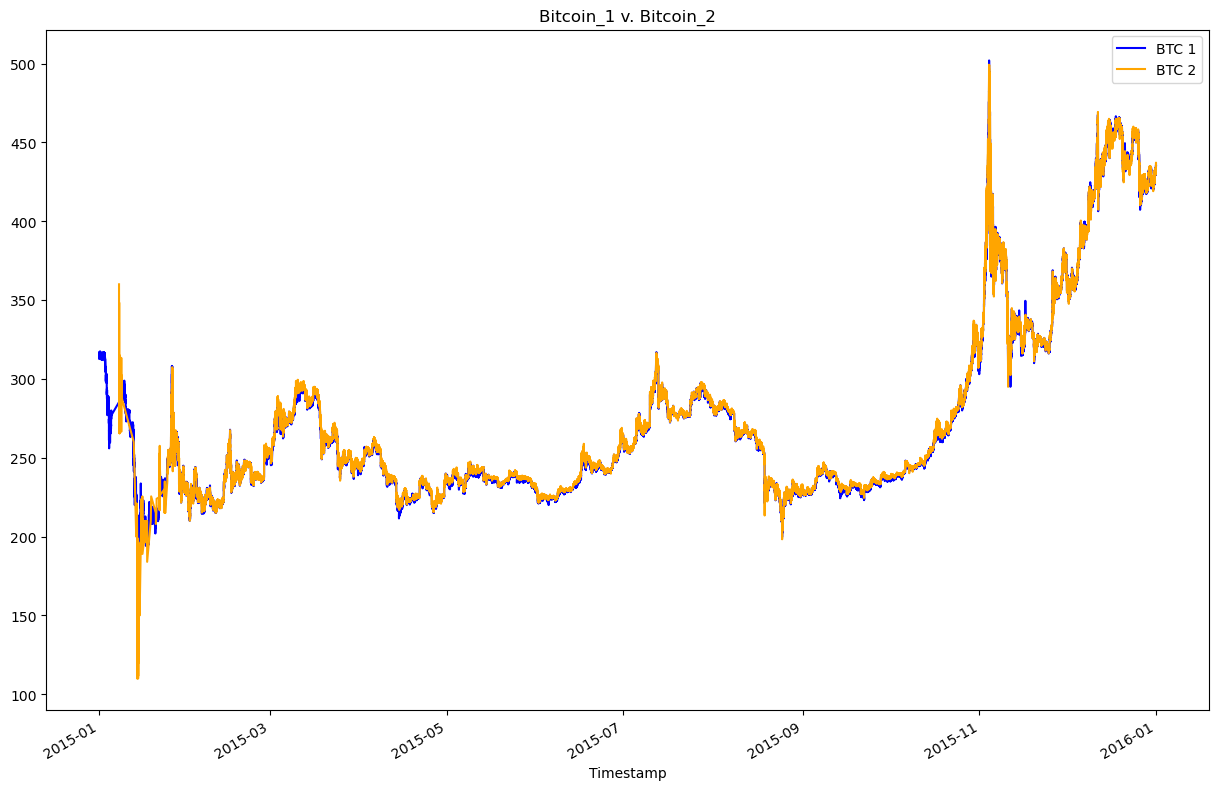

In [6]:
# Overlay the plot of the Bitcoin 'Close' data
bitcoin_1['Close'].plot(legend=True, figsize=(15, 10), title="Bitcoin_1 v. Bitcoin_2", color="blue", label="BTC 1")
bitcoin_2['Close'].plot(legend=True, figsize=(15, 10), color="orange", label="BTC 2")

## Step 1: Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a period of one month.

In [7]:
bitcoin_1.index

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 00:01:00',
               '2015-01-01 00:02:00', '2015-01-01 00:03:00',
               '2015-01-01 00:04:00', '2015-01-01 00:07:00',
               '2015-01-01 00:08:00', '2015-01-01 00:10:00',
               '2015-01-01 00:11:00', '2015-01-01 00:14:00',
               ...
               '2015-12-31 23:48:00', '2015-12-31 23:49:00',
               '2015-12-31 23:50:00', '2015-12-31 23:51:00',
               '2015-12-31 23:52:00', '2015-12-31 23:53:00',
               '2015-12-31 23:54:00', '2015-12-31 23:56:00',
               '2015-12-31 23:57:00', '2015-12-31 23:58:00'],
              dtype='datetime64[ns]', name='Timestamp', length=372773, freq=None)

In [8]:
# How to find the wrong order of datetime, important for loc['time':'time'] to use sort_index() to make sure the index is in order.
for i in range(1, len(bitcoin_1.index)):
    if(bitcoin_1.index[i] - bitcoin_1.index[i-1] < pd.Timedelta(0)):
        print(i, bitcoin_1.index[i], bitcoin_1.index[i-1])

303294 2015-11-01 01:00:00 2015-11-01 01:58:00


In [9]:
bitcoin_1.iloc[303292:303296]

,Close
Timestamp,
2015-11-01 01:56:00,316.22
2015-11-01 01:58:00,316.14
2015-11-01 01:00:00,315.53
2015-11-01 01:01:00,315.52


In [10]:
# Important for loc['time':'time'] to use sort_index() to make sure the index is in order.
bitcoin_1.sort_index().loc["2015-01-01": "2015-01-01"]
bitcoin_2.sort_index().loc["2015-01-01": "2015-01-01"]

,Close
Timestamp,


<Axes: title={'center': 'October 2015'}, xlabel='Timestamp'>

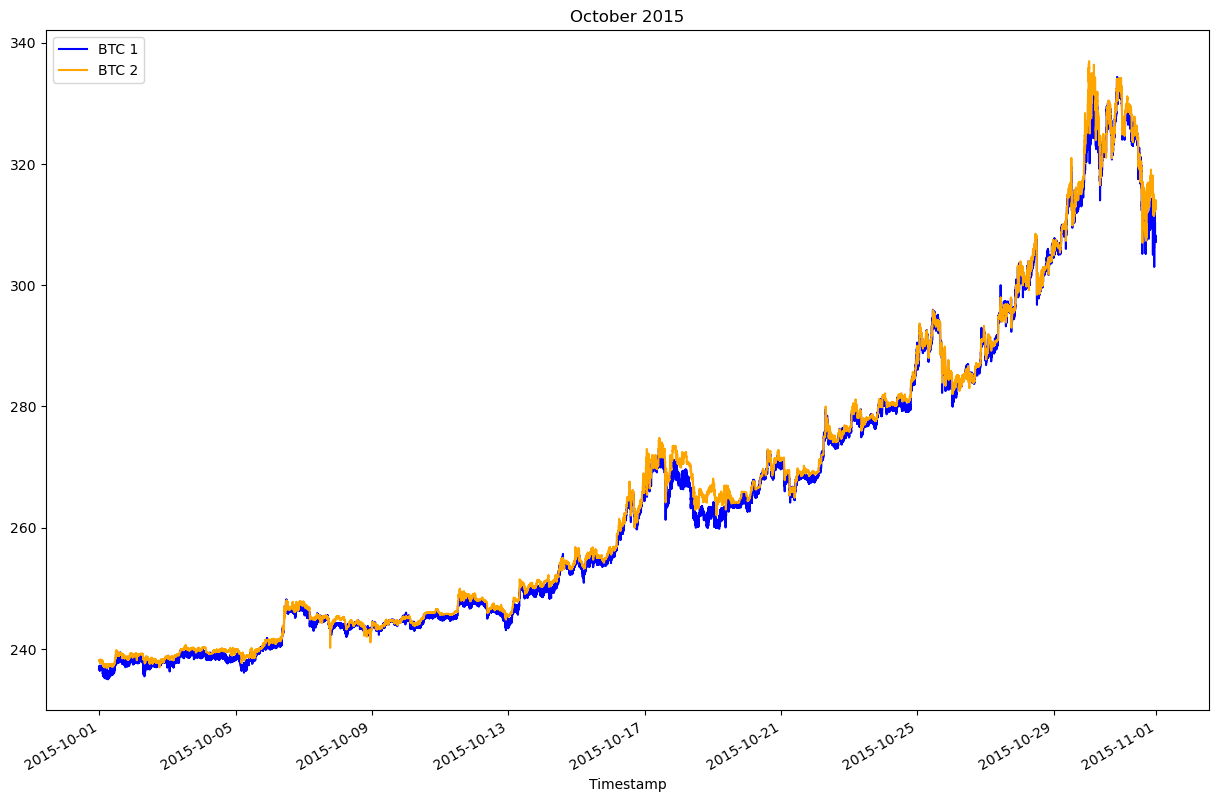

In [11]:
# Using the loc function, create an overlay plot that visualizes the two dataframes 
# over a period of one month
# Be sure that the plot includes the parameters `legend`, `figsize`, `title`, `color` and `label` 
bitcoin_1['Close'].sort_index().loc['2015-10-01':'2015-10-31'].plot(
    legend=True, figsize=(15, 10), title="October 2015", color="blue", label="BTC 1")
bitcoin_2['Close'].sort_index().loc['2015-10-01' : '2015-10-31'].plot(
 legend=True, figsize=(15, 10), color="orange", label="BTC 2")

## Step 2: Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a period of a week in the month that you selected.

<Axes: title={'center': 'October 18-24, 2015'}, xlabel='Timestamp'>

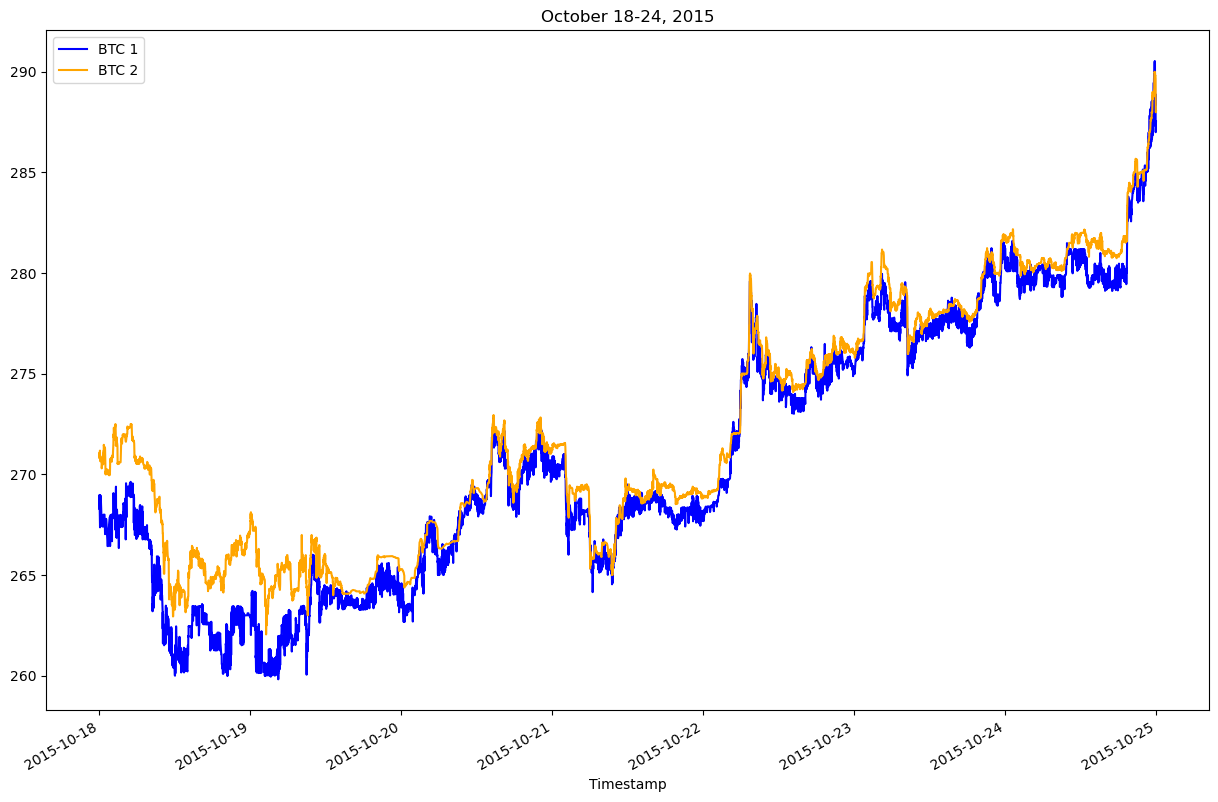

In [12]:
# Using the loc function, create an overlay plot that visualizes the two dataframes
# over a period of one week.
# The week should be included inside of the month that you previously selected 
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label`
bitcoin_1['Close'].sort_index().loc['2015-10-18':'2015-10-24'].plot(legend = True, figsize = (15,10), 
                                                                    title = 'October 18-24, 2015', 
                                                                    color = 'blue',label = 'BTC 1')
bitcoin_2['Close'].sort_index().loc['2015-10-18':'2015-10-24'].plot(legend = True, figsize = (15,10), 
                                                                
                                                                    color = 'orange',label = 'BTC 2')

## Step 3: Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a single day of the week that you selected.

<Axes: title={'center': 'October 19, 2015'}, xlabel='Timestamp'>

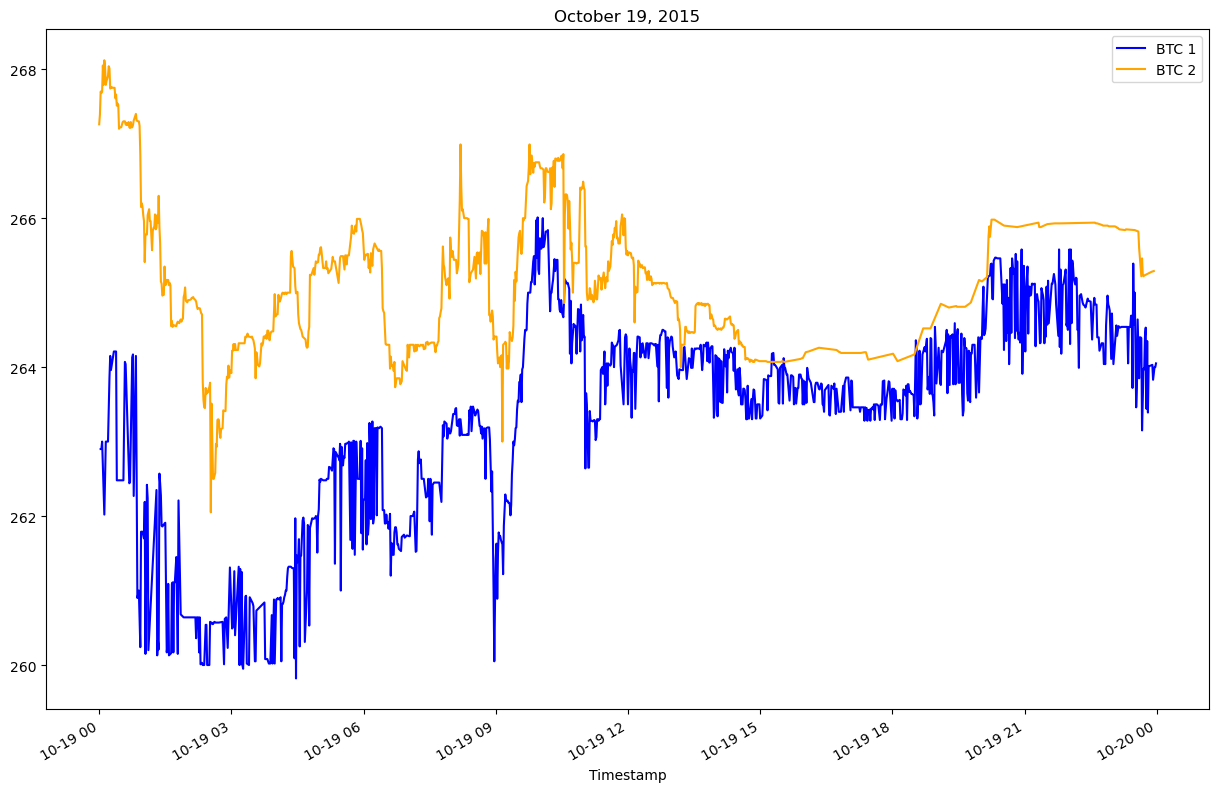

In [13]:
# Using the loc function, create an overlay plot that visualizes the two dataframes 
# over a period of one day.
# The day should be included inside of the week that was previsouly selected. 
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label` 
bitcoin_1['Close'].loc['2015-10-19'].plot(
    legend=True, figsize=(15, 10), title="October 19, 2015", color="blue", label="BTC 1")
bitcoin_2['Close'].loc['2015-10-19'].plot(
    legend=True, figsize=(15, 10), color="orange", label="BTC 2")

## Step 4: Using the Pandas `loc` function, create an overlay plot that illustrates the price differences between the two DataFrames over a couple of hours during the day that you selected.

<Axes: title={'center': 'October 19, 2015'}, xlabel='Timestamp'>

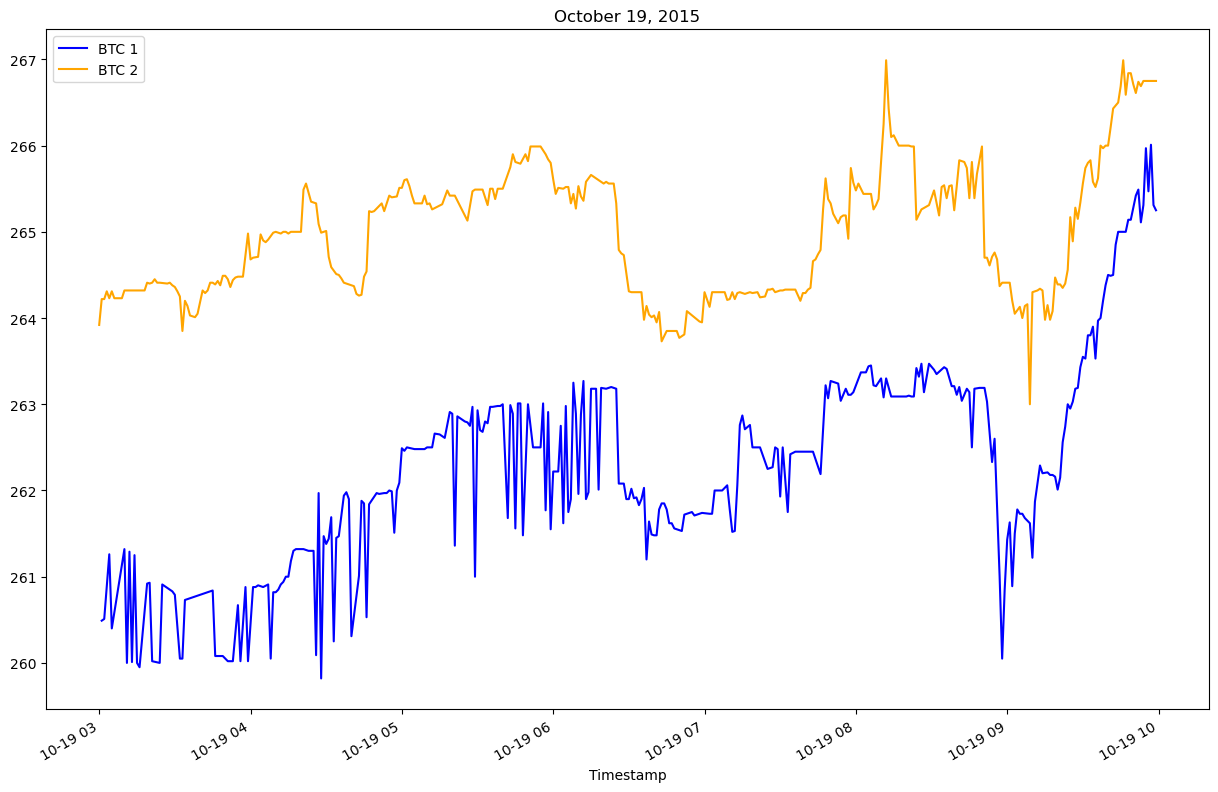

In [15]:
# Using the loc function, create an overlay plot that visualizes the two dataframes
# over a period of a couple of hours.
# The hours should be included inside of the day that was previously selected. 
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label`
bitcoin_1['Close'].sort_index().loc['2015-10-19 03' : '2015-10-19 09'].plot(
    legend=True, figsize=(15, 10), title="October 19, 2015", color="blue", label="BTC 1")
bitcoin_2['Close'].sort_index().loc['2015-10-19 03' : '2015-10-19 09'].plot(
    legend=True, figsize=(15, 10), color="orange", label="BTC 2")